In [32]:
%pip install pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\lokes\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [33]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\lokes\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(pd.__version__)
print(np.__version__)
print("Everything works!")

3.0.3
2.4.6
Everything works!


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", plt.__version__ if hasattr(plt, "__version__") else "Installed")

Pandas: 3.0.3
NumPy: 2.4.6
Matplotlib: Installed


In [36]:
import pandas as pd
import numpy as np
import matplotlib

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Matplotlib:", matplotlib.__version__)

Pandas: 3.0.3
NumPy: 2.4.6
Matplotlib: 3.11.0


In [37]:
fund_master = pd.read_csv("data/raw/01_fund_master.csv")
nav_history = pd.read_csv("data/raw/02_nav_history.csv")
scheme_performance = pd.read_csv("data/raw/07_scheme_performance.csv")
investor_transactions = pd.read_csv("data/raw/08_investor_transactions.csv")
benchmark = pd.read_csv("data/raw/10_benchmark_indices.csv")

print("All files loaded successfully!")

All files loaded successfully!


In [38]:
nav_history.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [39]:
nav_history.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


In [40]:
nav_history["date"] = pd.to_datetime(nav_history["date"])
nav_history = nav_history.sort_values(["amfi_code", "date"])

In [41]:
nav_history["daily_return"] = (
    nav_history.groupby("amfi_code")["nav"].pct_change()
)

In [42]:
results = []

for fund, group in nav_history.groupby("amfi_code"):
    returns = group["daily_return"].dropna()

    if len(returns) > 0:
        var95 = returns.quantile(0.05)
        cvar95 = returns[returns <= var95].mean()

        results.append({
            "amfi_code": fund,
            "VaR_95": var95,
            "CVaR_95": cvar95
        })

var_cvar_report = pd.DataFrame(results)

In [43]:
var_cvar_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [44]:
var_cvar_report.to_csv("var_cvar_report.csv", index=False)
print("var_cvar_report.csv saved successfully!")

var_cvar_report.csv saved successfully!


In [45]:
# Daily returns
nav_history["daily_return"] = nav_history.groupby("amfi_code")["nav"].pct_change()

# Rolling Sharpe Ratio
nav_history["rolling_sharpe"] = (
    nav_history.groupby("amfi_code")["daily_return"]
    .transform(lambda x: (x.rolling(90).mean() / x.rolling(90).std()) * np.sqrt(252))
)

nav_history.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
5750,100016,2022-01-03,520.4608,NaN,NaN
5751,100016,2022-01-04,515.0971,-0.010306,NaN
5752,100016,2022-01-05,521.7239,0.012865,NaN
5753,100016,2022-01-06,515.7880,-0.011377,NaN
5754,100016,2022-01-07,515.1639,-0.001210,NaN


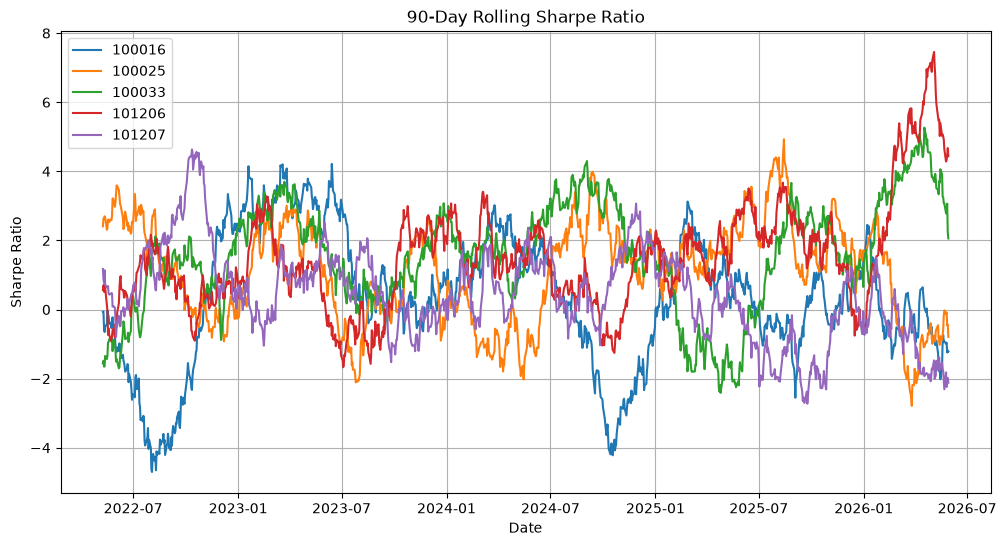

In [46]:
top5 = nav_history["amfi_code"].unique()[:5]

plt.figure(figsize=(12,6))

for fund in top5:
    temp = nav_history[nav_history["amfi_code"] == fund]
    plt.plot(temp["date"], temp["rolling_sharpe"], label=str(fund))

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig("rolling_sharpe_chart.png")
plt.show()

In [47]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

In [48]:
investor_transactions["cohort_year"] = (
    investor_transactions
    .groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

In [49]:
cohort_summary = investor_transactions.groupby("cohort_year").agg(
    avg_sip_amount=("amount_inr", "mean"),
    total_invested=("amount_inr", "sum"),
    investors=("investor_id", "nunique")
)

cohort_summary

,avg_sip_amount,total_invested,investors
cohort_year,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [50]:
cohort_summary

,avg_sip_amount,total_invested,investors
cohort_year,,,
2024,107422.541832,3491125187,4803
2025,109158.577061,30455243,197


In [51]:
investor_transactions["transaction_date"] = pd.to_datetime(
    investor_transactions["transaction_date"]
)

investor_transactions = investor_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

investor_transactions["gap_days"] = (
    investor_transactions.groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [52]:
at_risk_investors = investor_transactions[
    investor_transactions["gap_days"] > 35
]

at_risk_investors.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
24079,INV000001,2025-01-14,148569,Lumpsum,189483,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,71.0
12522,INV000002,2024-07-14,149323,Lumpsum,153187,Maharashtra,Pune,T30,46-55,Male,24.0,UPI,Verified,2024,107.0
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,69.0
24661,INV000002,2025-01-23,118632,Lumpsum,317170,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,112.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,114.0


In [53]:
print("Number of at-risk transactions:", len(at_risk_investors))
print("Number of unique at-risk investors:", at_risk_investors["investor_id"].nunique())

Number of at-risk transactions: 15153
Number of unique at-risk investors: 4527


In [54]:
risk_choice = "Moderate"   # Change to "Low", "Moderate", or "High"

recommendation = scheme_performance[
    scheme_performance["risk_grade"] == risk_choice
].sort_values("sharpe_ratio", ascending=False).head(3)

recommendation

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
5,100016,HDFC Top 100 Fund - Regular Plan - Growth,HDFC Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate


In [55]:
portfolio_holdings = pd.read_csv("data/raw/09_portfolio_holdings.csv")

portfolio_holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [56]:
sector_hhi = (
    portfolio_holdings.groupby(["amfi_code", "sector"])["weight_pct"]
    .sum()
    .reset_index()
)

sector_hhi["weight"] = sector_hhi["weight_pct"] / 100

hhi = (
    sector_hhi.groupby("amfi_code")["weight"]
    .apply(lambda x: (x**2).sum())
    .reset_index(name="HHI")
)

hhi.head()

,amfi_code,HHI
0,100016,0.180588
1,100033,0.227647
2,101206,0.180042
3,101207,0.222727
4,102885,0.180712


## Advanced Insights

1. Funds with higher Sharpe Ratios showed better risk-adjusted returns than other schemes.

2. Some mutual funds had higher Historical VaR and CVaR, indicating greater downside risk during adverse market conditions.

3. Investor cohorts from recent years showed higher average SIP investments, reflecting increased participation.

4. Investors with transaction gaps greater than 35 days were identified as at-risk, highlighting SIP discontinuity.

5. Sector HHI analysis showed that some funds are highly concentrated in a few sectors, while others are better diversified.

In [57]:
var_cvar_report.to_csv("var_cvar_report.csv", index=False)

In [58]:
hhi.to_csv("sector_hhi_report.csv", index=False)

In [59]:
recommendation.to_csv("recommendation.csv", index=False)

In [60]:
plt.savefig("rolling_sharpe_chart.png")

<Figure size 640x480 with 0 Axes>